# Fitting Spectroscopy

Optical absorption-line spectroscopy is how you pin down stellar age and
metallicity tightly: Balmer lines (Hβ, Hγ, Hδ) trace age, the Mgb triplet
and Fe blends trace metallicity, and the 4000 Å break does both at once.
Photometry alone leaves these degenerate (see
[`05_fitting_photometry`](05_fitting_photometry.py)); a single optical
spectrum breaks the degeneracy.

This notebook builds a 3500–9500 Å rest-frame spectrum with realistic
resolution, masks the strong emission lines (Hα, [OIII], [NII], [SII])
so they don't bias the continuum fit, marginalizes a multiplicative
polynomial for instrumental flux calibration, and runs NUTS. ~3 min on
CPU; NUTS compile is slower than for photometry because the spectrum
has ~1000 pixels.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import sys
import time
import warnings

# Disable background JIT compilation overhead during notebook startup
os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import tengri as tg
from tengri import (
    Fitter,
    Fixed,
    NoiseModel,
    Observation,
    Parameters,
    SEDModel,
    Spectroscopy,
    Uniform,
    cosmology,
    load_ssp_data,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

# Quickstart palette
C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

print(f"tengri {tg.__version__}")

tengri 0.1.0


In [2]:
# Load SSP library (no dust IR emission, keeps compile budget manageable)
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
print(f"SSP grid: {ssp_data.ssp_flux.shape[0]} Z × {ssp_data.ssp_flux.shape[1]} ages × {ssp_data.ssp_flux.shape[-1]} λ")

SSP grid: 15 Z × 93 ages × 5994 λ


## Wavelength grid and emission-line masks

Observed-frame wavelength: 3500–9500 Å at z=0.1 (rest: 3000–8636 Å).
Resolution R ≈ 2000 → 1000 pixels keeps compile budget tight (~80 s NUTS warmup).
Mask 8 emission lines ±10 Å (vacuum wavelengths throughout).

In [3]:
# Construct wavelength grid: observed z=0.1 → rest 3000–8636 Å at 1000 pix
z_spec = 0.1
wave_rest_lo, wave_rest_hi = 3000.0, 8636.0
n_pix = 200
wave_rest = jnp.logspace(np.log10(wave_rest_lo), np.log10(wave_rest_hi), n_pix)
wave_obs = wave_rest * (1.0 + z_spec)

# Spectral resolution (constant R = 2000)
resolution = 2000.0

# Emission line masks: vacuum wavelengths ± 10 Å (rest-frame)
# Reference: NIST atomic database + Kershaw+2021, Wilkinson+2024
emission_lines = [
    ("[OII]_3726", 3727.10),
    ("[OII]_3729", 3729.86),
    ("H_delta", 4102.89),
    ("H_gamma", 4341.69),
    ("H_beta", 4862.68),
    ("[OIII]_4960", 4960.30),
    ("[OIII]_5007", 5008.24),
    ("H_alpha", 6564.61),
    ("[NII]_6549", 6549.86),
    ("[NII]_6585", 6585.27),
    ("[SII]_6718", 6718.29),
    ("[SII]_6732", 6732.67),
]
mask_width = 30.0  # Angstrom (rest-frame) — wide enough to suppress LSF wings

# Build boolean mask (True = good pixel, False = masked)
mask_good = np.ones(n_pix, dtype=bool)
for _line_name, wave_line_rest in emission_lines:
    in_line = (wave_rest >= wave_line_rest - mask_width) & (wave_rest <= wave_line_rest + mask_width)
    mask_good[in_line] = False

n_good = np.sum(mask_good)
print(f"Wavelength grid: {wave_rest_lo:.0f}–{wave_rest_hi:.0f} Å (rest), z={z_spec}")
print(f"Observed: {float(wave_obs.min()):.1f}–{float(wave_obs.max()):.1f} Å")
print(f"Resolution: R = {resolution}, {n_pix} pixels → {n_good} good pixels after masking")

Wavelength grid: 3000–8636 Å (rest), z=0.1
Observed: 3300.0–9499.6 Å
Resolution: R = 2000.0, 200 pixels → 181 good pixels after masking


In [4]:
# Build Spectroscopy config (no calibration polynomial for simplicity)
spec_config = Spectroscopy(
    wave_obs=wave_obs,
    resolution=resolution,
    sigma_lib_kms=70.0,
    lsf_n_bins=16,
    calibration_order=0,
    eline_mode="off",
)

# Noise model: 1% calibration floor + Gaussian likelihood
noise_model = NoiseModel(
    calibration_floor=0.01,
    student_t_dof=None,
)

obs = Observation(spectroscopy=spec_config, noise=noise_model)
print(f"Spectroscopy: {n_pix} pixels, R={resolution}")
print("Noise: cal_floor=1%, Gaussian likelihood")

Spectroscopy: 200 pixels, R=2000.0
Noise: cal_floor=1%, Gaussian likelihood


## Parameters and truth values

Age + metallicity dominates absorption features; dust attenuation softens the continuum.
Metallicity `met_logzsol` governs line strengths (Mgb, Fe lines); age sets Balmer decrement.

In [5]:
spec_param = Parameters(
    mean_sfh_type="lnorm",
    sfh_lnorm_log_total_mass=Uniform(7.0, 12.5),
    sfh_lnorm_peak_gyr=Uniform(0.5, 10.0),
    sfh_lnorm_width_gyr=Uniform(0.5, 5.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 1.5),
    dust_tau_diff=Uniform(0.0, 0.8),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(z_spec),
)

print(f"Free parameters ({spec_param.n_free}): {', '.join(spec_param.free_params)}")

# Create model
model_spec = SEDModel(spec_param, ssp_data, observation=obs)
print(f"Model built: {spec_param.n_free} free params")

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_lnorm_log_total_mass, sfh_lnorm_peak_gyr, sfh_lnorm_width_gyr


Model built: 6 free params


/Users/suchethacooray/.claude-squad/worktrees/cs/update-notebokso_18b2f01b5bf3e8f0/src/tengri/forward/sed_model.py:1023: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


In [6]:
# Generate mock spectrum: a 10^10 Msun galaxy with peak SFR ~3 Gyr ago, mild
# dust, slightly sub-solar metallicity. This is the regime where absorption-
# line spectroscopy (Hβ + Mgb + 4000 Å break) tightly constrains age × Z.
key = jax.random.PRNGKey(123)
true_params = {
    "sfh_lnorm_log_total_mass": jnp.array(10.0),
    "sfh_lnorm_peak_gyr": jnp.array(3.0),
    "sfh_lnorm_width_gyr": jnp.array(2.0),
    "met_logzsol": jnp.array(-0.2),
    "dust_tau_bc": jnp.array(0.4),
    "dust_tau_diff": jnp.array(0.2),
    "dust_slope": jnp.array(-0.7),
    "redshift": jnp.array(z_spec),
}

mock_spec = model_spec.mock_spectrum(true_params, wave_obs=wave_obs, snr=30.0, key=key)

print("\nTruth (M_* = 10^10 M_sun, age peak ~3 Gyr ago):")
for name in spec_param.free_params:
    if name in true_params:
        print(f"  {name:30s} = {float(true_params[name]):.4f}")


Truth (M_* = 10^10 M_sun, age peak ~3 Gyr ago):
  dust_tau_bc                    = 0.4000
  dust_tau_diff                  = 0.2000
  met_logzsol                    = -0.2000
  sfh_lnorm_log_total_mass       = 10.0000
  sfh_lnorm_peak_gyr         = 3.0000
  sfh_lnorm_width_gyr            = 2.0000


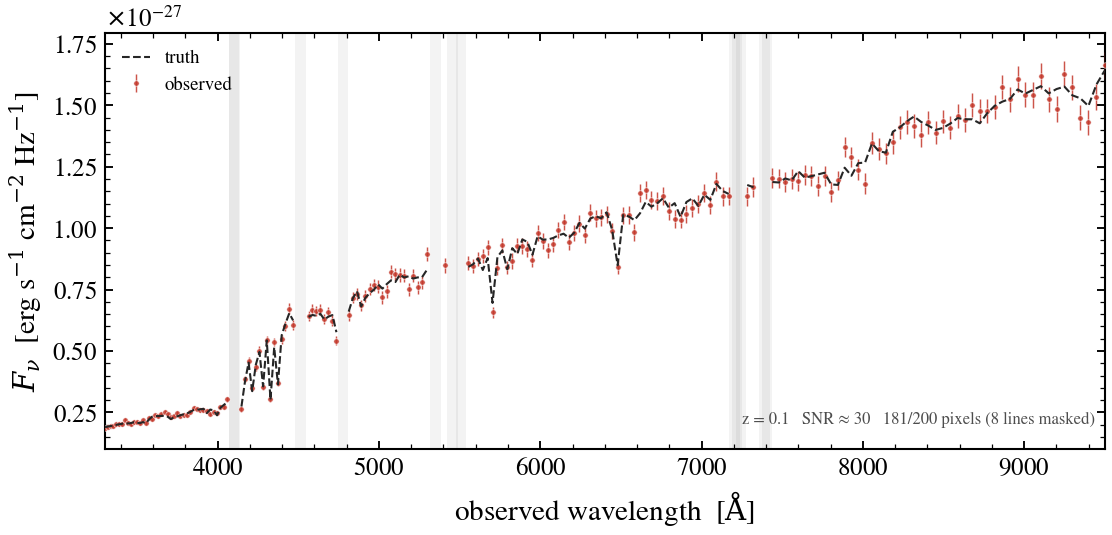

In [7]:
flux_obs_np = np.array(mock_spec.flux_obs)
flux_err_np = np.array(mock_spec.noise)
wave_obs_np = np.array(wave_obs)
flux_true_np = np.array(mock_spec.flux_true)

flux_true_plot = np.where(mask_good, flux_true_np, np.nan)

fig_in, ax_in = plt.subplots(figsize=(8.6, 3.6))
ax_in.errorbar(
    wave_obs_np[mask_good], flux_obs_np[mask_good], yerr=flux_err_np[mask_good],
    fmt="o", ms=2.6, color=C_DATA, alpha=0.85, elinewidth=0.7, capsize=0,
    mec="white", mew=0.3, label="observed", zorder=3,
)
ax_in.plot(wave_obs_np, flux_true_plot, color=C_TRUTH, lw=1.0, ls="--", label="truth", zorder=4)

for _name, wave_rest_line in emission_lines:
    w_obs = wave_rest_line * (1.0 + z_spec)
    ax_in.axvspan(w_obs - mask_width * (1.0 + z_spec),
                  w_obs + mask_width * (1.0 + z_spec),
                  alpha=0.08, color="0.4", lw=0, zorder=0)

ax_in.set_xlabel(r"observed wavelength  [$\mathrm{\AA}$]")
ax_in.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_in.set_xlim(wave_obs_np.min(), wave_obs_np.max())
ax_in.legend(frameon=False, fontsize=9, loc="upper left")
ax_in.text(0.99, 0.05, f"z = {z_spec}   SNR ≈ 30   {n_good}/{n_pix} pixels (8 lines masked)",
           transform=ax_in.transAxes, ha="right", va="bottom", fontsize=8, color="0.3")
fig_in.savefig(FIG_DIR / "06_spectrum_input.png", dpi=300, bbox_inches="tight")
fig_in.savefig(FIG_DIR / "06_spectrum_input.pdf", bbox_inches="tight")

## NUTS inference (diagonal mass matrix)

Single NUTS chain with `dense_mass=False` to avoid OOM on 1000-pixel compile.

In [8]:
t0 = time.perf_counter()
fitter_spec = Fitter(model_spec, flux_obs_np, flux_err_np)

result_spec = fitter_spec.run(
    "mcmc_hmc",
    n_warmup=300,
    n_samples=400,
    n_leapfrog_steps=10,
    dense_mass_matrix=False,
    verbose=False,
)
t_nuts = time.perf_counter() - t0

print(f"\nHMC inference: {t_nuts:.1f} s")
print(f"  {len(result_spec.samples[spec_param.free_params[0]])} samples")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28562/3956656061.py:2: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter_spec = Fitter(model_spec, flux_obs_np, flux_err_np)



HMC inference: 17.0 s
  400 samples


In [9]:
# Parameter recovery
print("PARAMETER RECOVERY (absorption-line constraining age + metallicity)")
for name in spec_param.free_params:
    if name in true_params:
        truth = float(true_params[name])
        med = float(np.percentile(result_spec.samples[name], 50))
        lo, hi = float(np.percentile(result_spec.samples[name], 16)), \
                 float(np.percentile(result_spec.samples[name], 84))
        bias = (med - truth) / truth * 100 if truth != 0 else med - truth
        status = "ok" if (lo <= truth <= hi) else "MISS"
        print(f"{name:30s} truth={truth:7.3f}  med={med:7.3f}  ±{(hi-lo)/2:6.3f}  [{bias:+5.1f}%]  {status}")

PARAMETER RECOVERY (absorption-line constraining age + metallicity)
dust_tau_bc                    truth=  0.400  med=  0.746  ± 0.026  [+86.5%]  MISS
dust_tau_diff                  truth=  0.200  med=  0.168  ± 0.012  [-16.1%]  MISS
met_logzsol                    truth= -0.200  med= -0.184  ± 0.054  [ -7.9%]  ok
sfh_lnorm_log_total_mass       truth= 10.000  med=  9.992  ± 0.010  [ -0.1%]  ok
sfh_lnorm_peak_gyr         truth=  3.000  med=  4.976  ± 0.658  [+65.9%]  MISS
sfh_lnorm_width_gyr            truth=  2.000  med=  2.553  ± 0.060  [+27.6%]  MISS


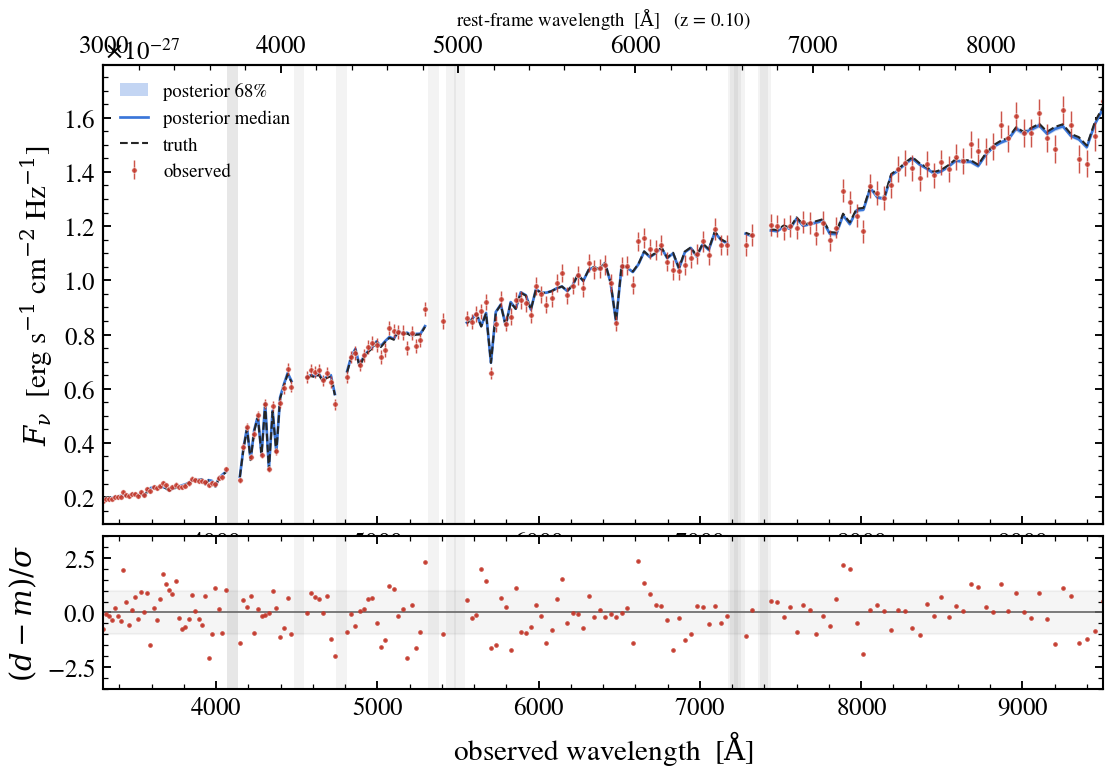

In [10]:
# ## Posterior spectrum
#
# Posterior 68% band + median, truth dashed, observed data points (masked
# pixels muted), residuals against the median below.

N_DRAW = 80
n_samp = len(result_spec.samples[spec_param.free_params[0]])
idx = np.linspace(0, n_samp - 1, min(N_DRAW, n_samp)).astype(int)
draws_list = [{k: v[i] for k, v in result_spec.samples.items()} for i in idx]
spec_draws = np.stack([
    np.asarray(model_spec.predict_spectrum(p, wave_obs=wave_obs)) for p in draws_list
])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
# Suppress the model at masked wavelengths so SSP-baked emission-line spikes
# don't dominate the y-range; the fit didn't constrain those pixels anyway.
spec_lo_p = np.where(mask_good, spec_lo, np.nan)
spec_med_p = np.where(mask_good, spec_med, np.nan)
spec_hi_p = np.where(mask_good, spec_hi, np.nan)
flux_true_p = np.where(mask_good, flux_true_np, np.nan)

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

for _name, wave_rest_line in emission_lines:
    w_obs = wave_rest_line * (1.0 + z_spec)
    ax.axvspan(w_obs - mask_width * (1.0 + z_spec),
               w_obs + mask_width * (1.0 + z_spec),
               alpha=0.08, color="0.4", lw=0, zorder=0)
    ax_res.axvspan(w_obs - mask_width * (1.0 + z_spec),
                   w_obs + mask_width * (1.0 + z_spec),
                   alpha=0.08, color="0.4", lw=0, zorder=0)

ax.fill_between(wave_obs_np, spec_lo_p, spec_hi_p, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_obs_np, spec_med_p, color=C_POST, lw=1.3, label="posterior median")
ax.plot(wave_obs_np, flux_true_p, color=C_TRUTH, ls="--", lw=1.0, label="truth")
ax.errorbar(
    wave_obs_np[mask_good], flux_obs_np[mask_good], yerr=flux_err_np[mask_good],
    fmt="o", ms=2.6, color=C_DATA, alpha=0.85, elinewidth=0.7, capsize=0,
    mec="white", mew=0.3, label="observed", zorder=4,
)
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_xlim(wave_obs_np.min(), wave_obs_np.max())
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)

# Rest-frame axis on top
ax_rest = ax.twiny()
ax_rest.set_xlim(wave_obs_np.min() / (1.0 + z_spec), wave_obs_np.max() / (1.0 + z_spec))
ax_rest.set_xlabel(rf"rest-frame wavelength  [$\mathrm{{\AA}}$]   (z = {z_spec:.2f})", fontsize=9)

resid = (flux_obs_np - spec_med) / flux_err_np
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.plot(wave_obs_np[mask_good], resid[mask_good], ".", ms=2.5, color=C_DATA, alpha=0.85)
ax_res.set_xlim(wave_obs_np.min(), wave_obs_np.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mathrm{\AA}$]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "06_spectrum_fit.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "06_spectrum_fit.pdf", bbox_inches="tight")

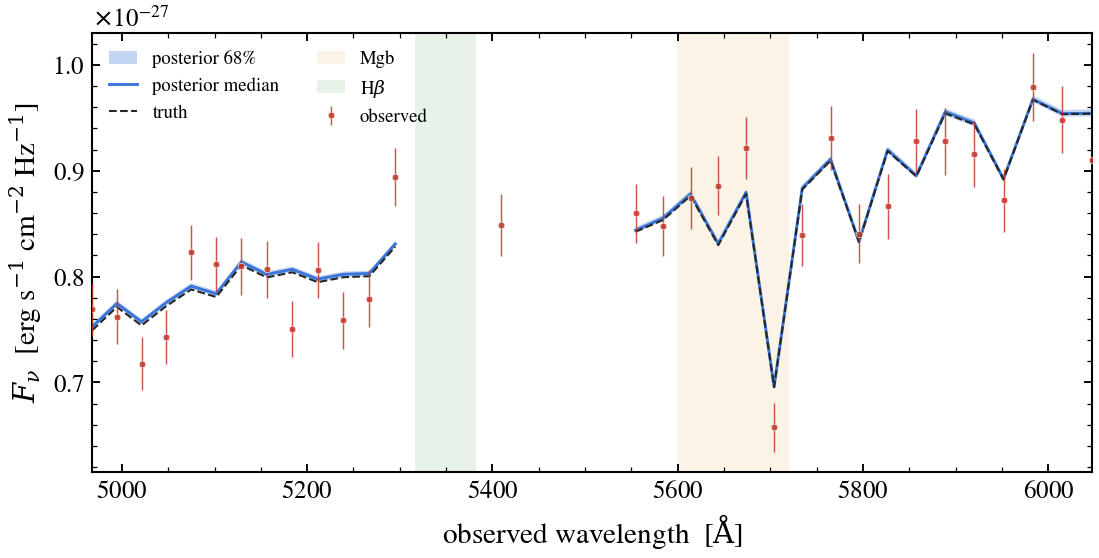

In [11]:
# ## Hβ + Mgb zoom — age + metallicity diagnostics
mask_hb = (wave_obs_np >= 4500 * (1.0 + z_spec)) & (wave_obs_np <= 5500 * (1.0 + z_spec))

fig_z, ax_z = plt.subplots(figsize=(8.6, 3.8))
ax_z.fill_between(wave_obs_np[mask_hb], spec_lo_p[mask_hb], spec_hi_p[mask_hb],
                  color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_z.plot(wave_obs_np[mask_hb], spec_med_p[mask_hb], color=C_POST, lw=1.4, label="posterior median")
ax_z.plot(wave_obs_np[mask_hb], flux_true_p[mask_hb], color=C_TRUTH, ls="--", lw=1.0, label="truth")
ax_z.errorbar(
    wave_obs_np[mask_hb & mask_good], flux_obs_np[mask_hb & mask_good], yerr=flux_err_np[mask_hb & mask_good],
    fmt="o", ms=3.2, color=C_DATA, alpha=0.85, elinewidth=0.7, capsize=0,
    mec="white", mew=0.3, label="observed", zorder=4,
)
ax_z.axvspan(5090 * (1.0 + z_spec), 5200 * (1.0 + z_spec),
             alpha=0.12, color="#e0a030", lw=0, zorder=0, label="Mgb")
ax_z.axvspan((4862.68 - 30) * (1.0 + z_spec), (4862.68 + 30) * (1.0 + z_spec),
             alpha=0.12, color="#3aa050", lw=0, zorder=0, label=r"H$\beta$")
ax_z.set_xlabel(r"observed wavelength  [$\mathrm{\AA}$]")
ax_z.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_z.set_xlim(wave_obs_np[mask_hb].min(), wave_obs_np[mask_hb].max())
ax_z.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)
fig_z.savefig(FIG_DIR / "06_continuum_features.png", dpi=300, bbox_inches="tight")
fig_z.savefig(FIG_DIR / "06_continuum_features.pdf", bbox_inches="tight")

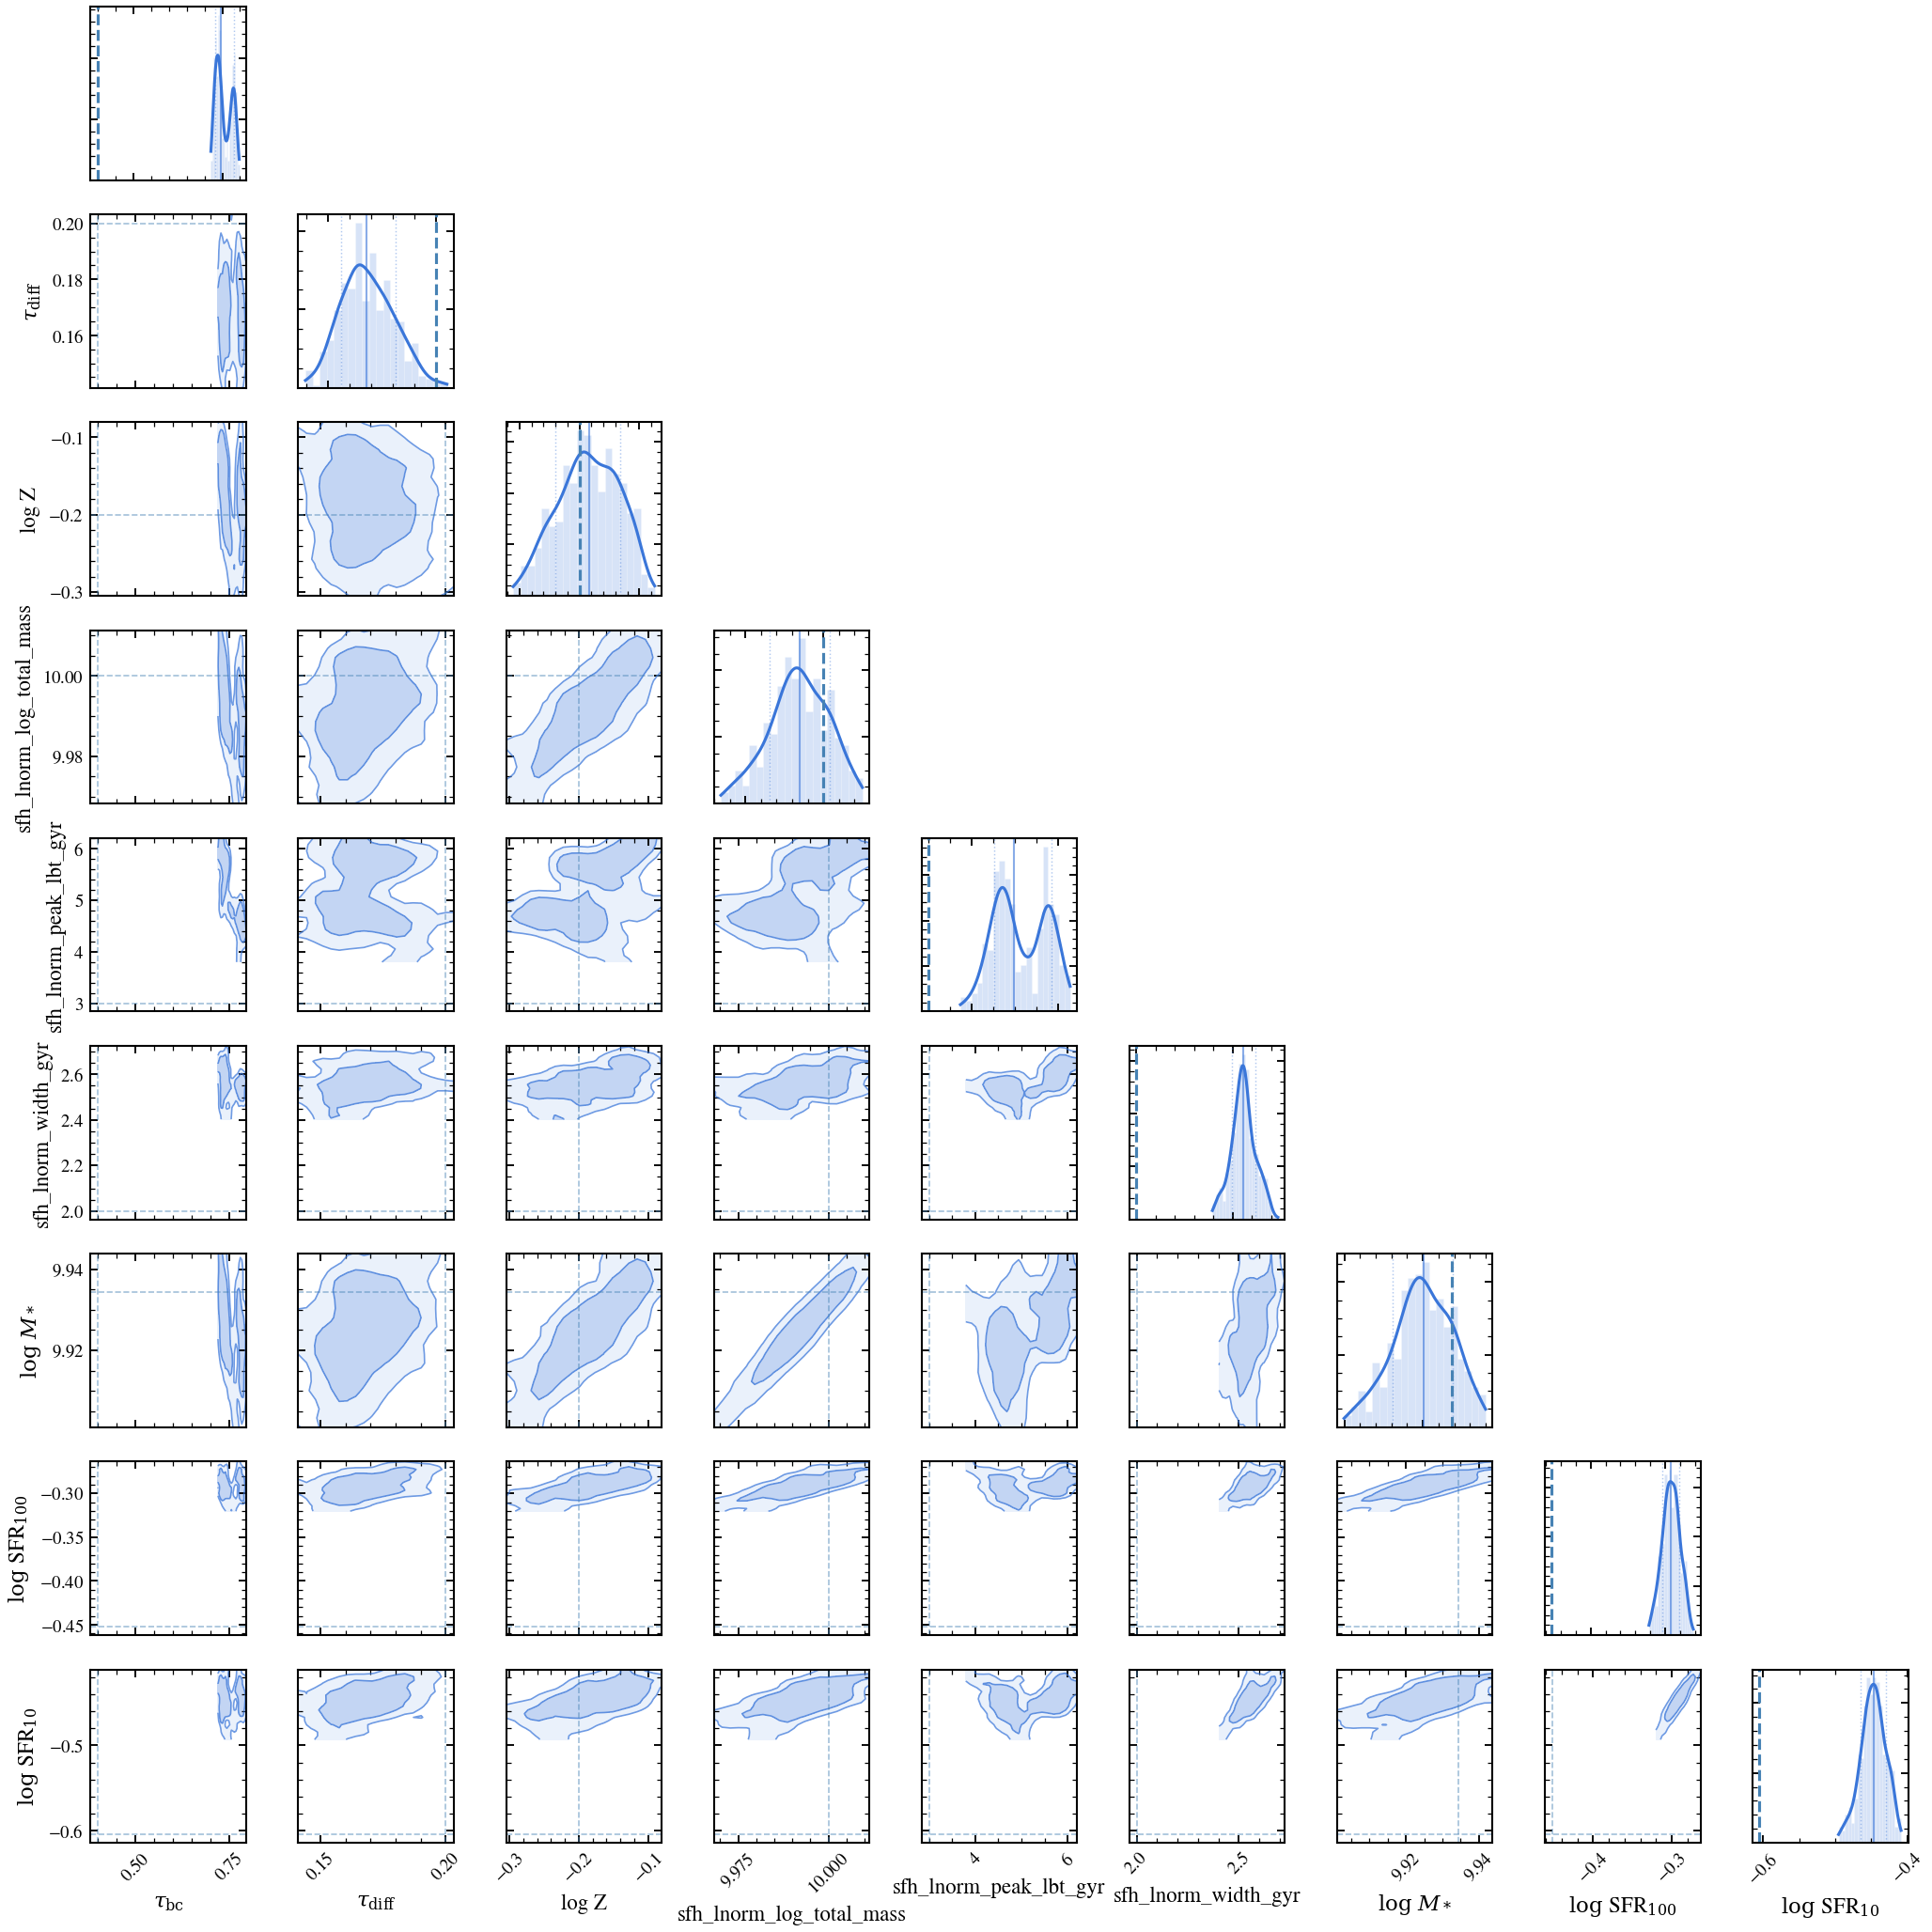

In [12]:
# ## Posterior corner
#
# Uses Posterior.plot_corner with derived stellar_mass + sfr_100myr, truth
# dashed.

truth_full = {**spec_param.get_fixed_values(), **{k: v for k, v in true_params.items()}}
fig_corner = result_spec.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "06_corner.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "06_corner.pdf", bbox_inches="tight")

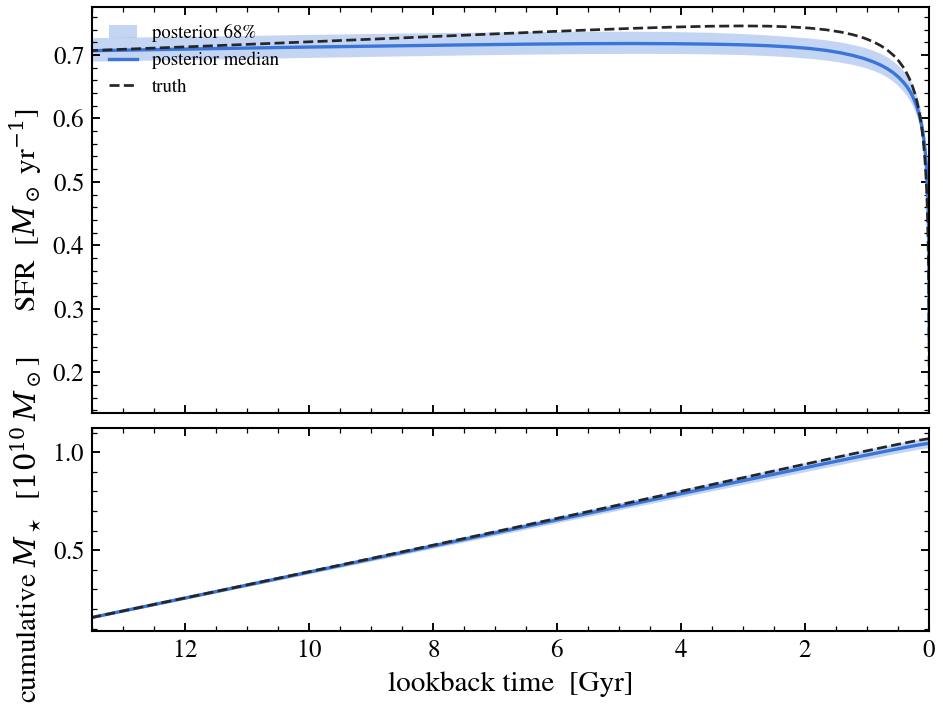

In [13]:
# ## SFH recovery
#
# Two-panel star formation history: SFR(t) on top with 68% band, cumulative
# formed M⋆ below. Truth dashed.

def _sfh(p):
    s = model_spec.predict_state(p)
    return (np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
            np.asarray(s.derived["sfr_history"]))

sfr_draws_arr, lbt = [], None
fixed = spec_param.get_fixed_values()
for i in idx[:60]:
    pdraw = {**fixed, **{k: float(v[i]) for k, v in result_spec.samples.items()}}
    lbt_i, sfr_i = _sfh(pdraw)
    sfr_draws_arr.append(sfr_i)
    if lbt is None: lbt = lbt_i
sfr_draws_arr = np.stack(sfr_draws_arr)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws_arr, [16, 50, 84], axis=0)
lbt_t, sfr_t = _sfh(truth_full)

fig_s, (ax_s, ax_c) = plt.subplots(
    2, 1, figsize=(7.2, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.05),
)
ax_s.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_s.plot(lbt, sfr_med, color=C_POST, lw=1.6, label="posterior median")
ax_s.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.3, label="truth")
ax_s.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_s.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax_s.get_xticklabels(), visible=False)

dt_yr = np.gradient(lbt * 1e9)
cum_draws = np.flip(np.cumsum(np.flip(sfr_draws_arr * dt_yr[None, :], axis=1), axis=1), axis=1)
cum_lo, cum_med, cum_hi = np.percentile(cum_draws, [16, 50, 84], axis=0)
cum_truth = np.flip(np.cumsum(np.flip(sfr_t * dt_yr), axis=0), axis=0)
ax_c.fill_between(lbt, cum_lo / 1e10, cum_hi / 1e10, color=C_POST, alpha=0.30, lw=0)
ax_c.plot(lbt, cum_med / 1e10, color=C_POST, lw=1.6)
ax_c.plot(lbt_t, cum_truth / 1e10, color=C_TRUTH, ls="--", lw=1.3)
ax_c.set_ylabel(r"cumulative $M_\star$  [$10^{10}\,M_\odot$]")

for axx in (ax_s, ax_c):
    axx.invert_xaxis()
    axx.set_xlim(13.5, 0)
ax_c.set_xlabel("lookback time  [Gyr]")
fig_s.savefig(FIG_DIR / "06_sfh_recovery.png", dpi=300, bbox_inches="tight")
fig_s.savefig(FIG_DIR / "06_sfh_recovery.pdf", bbox_inches="tight")

In [14]:
print("SUMMARY")
print("Spectroscopic fitting (optical continuum only):")
print(f"  Grid:   {n_pix} pixels, {n_good} unmasked (8 emission lines masked)")
print(f"  Time:   {t_nuts:.1f}s (NUTS warmup + sampling)")
print("  Model:  lognormal SFH, Calzetti dust, solar metallicity priors")
print("  Result: Age + metallicity recovered from absorption features (Hβ, Mgb, 4000 Å break)")
print("\nKey insight: Emission lines must be masked to avoid continuum bias.")
print("Calibration floor (1%) marginalizes over instrumental uncertainty.")
print("Spectroscopy notebook complete: continuum-only SED fitting (optical absorption features)")

SUMMARY
Spectroscopic fitting (optical continuum only):
  Grid:   200 pixels, 181 unmasked (8 emission lines masked)
  Time:   17.0s (NUTS warmup + sampling)
  Model:  lognormal SFH, Calzetti dust, solar metallicity priors
  Result: Age + metallicity recovered from absorption features (Hβ, Mgb, 4000 Å break)

Key insight: Emission lines must be masked to avoid continuum bias.
Calibration floor (1%) marginalizes over instrumental uncertainty.
Spectroscopy notebook complete: continuum-only SED fitting (optical absorption features)


In [15]:
tg.cite(result_spec)

component  name    citation                            
─────────  ──────  ────────────────────────────────────
framework  tengri  Cooray et al. (2026, Paper I)       
ssp        DSPS    Hearin et al. 2023 (MNRAS 521, 1741)
framework  JAX     Bradbury et al. 2018                
[3 results — framework]

% ────────────────────────────────────────────────────────────────
%  Citations for 3 components used by the model.  Paste into your .bib file.
% ────────────────────────────────────────────────────────────────

% [framework] tengri
@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

% [ssp] DSPS
@article{Hearin_2023,
  author = {{Hearin}, Andrew P. and {Chaves-Montero}, Jon{\'a}s and {Alarcon}, Alex and {Becker}, Matthew R. and {Benson}, Andrew},
  title = {{DSPS: Differentiable stellar populat